# Building  The Computation Graph
- in the following we will build class that help us performing the backpropagation in NN 
- the _backward function attribute is used to back probagate the gradients to the previous nodes (from right to left)

## Note the diffrence
- out._backward = _backward() -> this is a function call
- out._backward = _backward -> we just store the function into an attribute

##  How to Automatic Propagating the Gradients to the previous nodes
- form a list of the graoh nodes ordered from the most right to the left
- loop through the list and call the _backward() of each node to propagate the gradient to the previous nodes

## Note the difference between _backward() and backward()
- backward() will be invoked only by the last node in the graph, it will initiate the back propagation Process

## Note that the Gradients mostly are Multivariate 
- so the gradient of a node accumulated by more than one node 

In [25]:
import random
import numpy as np
import math

In [26]:
# -*- coding: utf-8 -*-
"""
Spyder Editor

This is a temporary script file.
"""
class Value:
    
    def __init__(self, data, _children=(), _op='', label=''):
        self.data=data
        self._prev = _children     #factors produced the node
        _backward = lambda : None  #attribute that holds a function
        self._op = _op     
        self.label = label #node name
        self.grad=0.0
        
    def __repr__(self): #how to print the object of type Value (must return string)
        return f"Value = {self.data}"

    def __rmul__(self, other): # other * self
        return self * other
    
    def __add__(self,other):
        other = other if isinstance(other, Value) else Value(other) #casting if not of type Value
        out = Value( (self.data+other.data), (self,other), '+')
        
        def _backward():
            self.grad+=out.grad
            other.grad+=out.grad
            
        out._backward=_backward
        return out
        
    def __mul__(self,other):
        other = other if isinstance(other, Value) else Value(other) #casting if not of type Value
        out = Value( data=self.data*other.data, _children=(self,other), _op='*')
        
        def _backward():
            self.grad+=other.data*out.grad
            other.grad+=self.data*out.grad
    
        out._backward=_backward
        return out

    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
        out = Value(t, (self, ), 'tanh')
    
        
        def _backward():
            self.grad+=(1-out.data**2)*out.grad  #why multiplied by out.grad??
        out._backward=_backward
        return out

    def exp(self):
        x = self.data
        
        out = Value( (math.exp(x)), (self,), 'exp')
        
        def _backward():
            self.grad+= (out.data*out.grad)
            
        out._backward=_backward
        return out

    
    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only supporting int/float powers for now"
        out = Value(self.data**other, (self,), f'**{other}')

        def _backward():
            self.grad += (other * self.data**(other-1)) * out.grad
        out._backward = _backward

        return out
        
    def __neg__(self): # -self
        return self * -1
        
    def __sub__(self, other): # self - other
        return self + (-other)

    def __truediv__(self, other): # self / other
        return self * other**-1
    
    def backward(self):
        visited = set()
        topo = [] 
        if self not in visited:
            visited.add(v)
            for i in v._prev:
                build_topo(i)
            topo.append(v) 
            
        self.grade = 1  #special case for the last node (dj/dj)
        for node in topo:
            topo._backward()
 


In [27]:
        
a = Value(data=2.0, label='a')
b = Value(data=-3.0, label='b')
c = Value(data=10.0, label='c')

e = a*b
e.label = 'e'
 
d = e + c
d.label = 'd'
 
f = Value(-2.0, label='f')

L = d * f
L.label = 'L'
L

Value = -8.0

# Neuron
- lets build the basic block of out Neural Network
- takes vector x as input 
- evaluate w.x+b 
- apply activation on w.x+b
- produce the output 

In [29]:
class Neuron:
  '''
  nin : size of the input features x
  x : the input features itself
  '''
  def __init__(self, nin):
    self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
    self.b = Value(random.uniform(-1,1))
  
  def __call__(self, x):
    # w * x + b
    act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
    out = act.tanh()
    return out
  
  def parameters(self):
    return self.w + [self.b] #concatenation

# Layer
- consists of no. of neurons equals to the no. of output activations required from the layer
- each neuron has inputs which is the inputs of the layer itself

In [31]:
class Layer:
  
  def __init__(self, nin, nout):
    self.neurons = [Neuron(nin) for _ in range(nout)]
  
  def __call__(self, x):
    outs = [n(x) for n in self.neurons]
    return outs[0] if len(outs) == 1 else outs
  
  def parameters(self):
    return [p for neuron in self.neurons for p in neuron.parameters()]

# Muli Layer Perceptron Neural Network
- we must sppecify the no. of layers
- we must sppecify the no. of neurons for each layer

In [33]:
class MLP:
  '''
  nin   : input features for the input layer
  nouts : how many outputs for each layer (no. of neurons in each layer)
  x     : input features & output activations (input to the next layer)
  sz    : list contains no. of neurons in each layer
  '''
    
  def __init__(self, nin, nouts): 
    sz = [nin] + nouts   #concatenation
    self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))] 
  
  def __call__(self, x):
    for layer in self.layers:
      x = layer(x)   #apply the output of each layer as input to the next 
    return x
  
  def parameters(self):
    return [p for layer in self.layers for p in layer.parameters()]

# Create the Network 

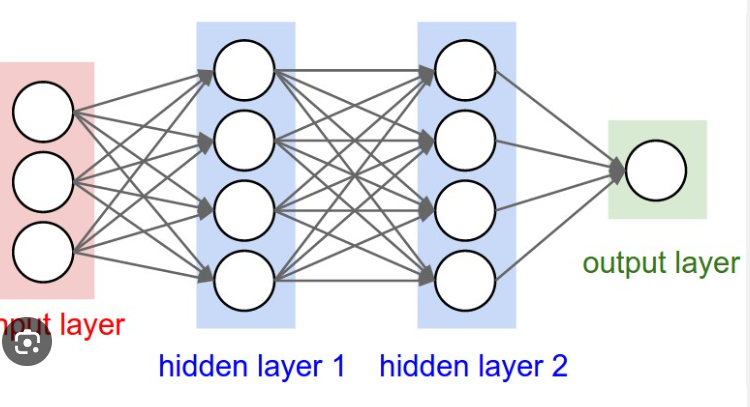

In [35]:
network = MLP(3,[4,4,1])
input_features = [2,3,-1]
network(input_features)

Value = 0.3403150427758651

In [36]:
def training(X, y, no_of_layers, neurons_in_each_layer, learning_rate, iterations, batch_size):

    X,y = data_loader(batch_size)
    
    #forward pass
    cost=0.0
    while(iterations):
        network = MLP(len(X), neurons_in_each_layer,)
        prediction = network(X)
    
        #backward 
        cost = sum ([ (y_i - prediction_i)**2 for y_i,prediction_i in zip(y,prediction)])/len(y)
        param = network.parameters()
    
        #intailize grad
        for p in param:
            p.grad= 0.0
    
        cost.backward()
    
        #update parameters
        for p in param:
            p.data += -learning_rate*p.grad
            
        iterations-=1

In [20]:
def data_loader( batch_size=None):
    # inline DataLoader :)
    if batch_size is None:
        Xb, yb = X, y
    else:
        ri = np.random.permutation(X.shape[0])[:batch_size]
        Xb, yb = X[ri], y[ri]

    return xb,yb
    